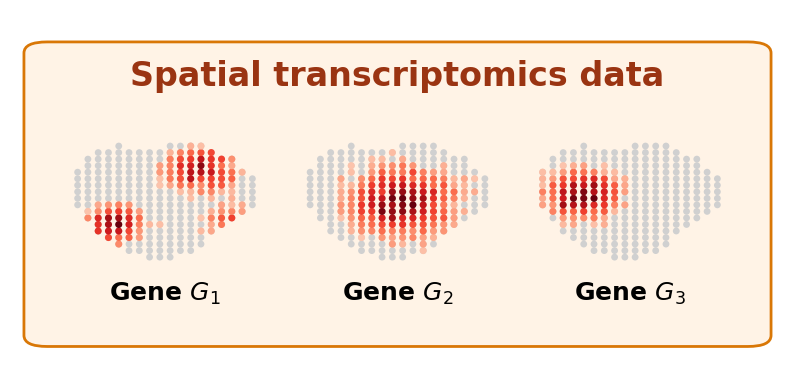

In [11]:
# ============================================================
# CARD 1: Spatial transcriptomics data
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.path import Path

np.random.seed(1)

def tissue_points(n_side=20):
    xs = np.linspace(0.08, 0.92, n_side)
    ys = np.linspace(0.08, 0.92, n_side)
    xx, yy = np.meshgrid(xs, ys)
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    poly = np.array([
        [0.08, 0.64], [0.14, 0.78], [0.28, 0.88], [0.49, 0.86],
        [0.61, 0.92], [0.78, 0.80], [0.92, 0.62], [0.86, 0.42],
        [0.72, 0.30], [0.65, 0.16], [0.48, 0.10], [0.32, 0.18],
        [0.20, 0.31], [0.11, 0.46]
    ])
    return pts[Path(poly).contains_points(pts)]

def signal(pts, mode="multi"):
    x, y = pts[:, 0], pts[:, 1]
    if mode == "multi":
        z = (
            0.9*np.exp(-((x-0.28)**2+(y-0.35)**2)/0.018)
            + 0.8*np.exp(-((x-0.65)**2+(y-0.72)**2)/0.028)
            + 0.5*np.exp(-((x-0.78)**2+(y-0.35)**2)/0.020)
        )
    elif mode == "center":
        z = np.exp(-((x-0.52)**2+(y-0.50)**2)/0.060)
    else:
        z = np.exp(-((x-0.30)**2+(y-0.55)**2)/0.030)
    z = z + 0.06*np.random.randn(len(z))
    z = np.clip(z, 0, None)
    return z / (z.max() + 1e-12)

def draw_tissue(ax, x, y, w, h, mode, label):
    pts = tissue_points()
    z = signal(pts, mode)
    xs = x + w*pts[:,0]
    ys = y + h*pts[:,1]
    ax.scatter(xs, ys, s=24, color="#d0d0d0", edgecolors="none", zorder=2)
    m = z > 0.22
    ax.scatter(xs[m], ys[m], s=26, c=z[m], cmap="Reds", vmin=0, vmax=1,
               edgecolors="none", zorder=3)
    ax.text(x + 0.5*w, y - 0.035*h, label, ha="center", va="top",
            fontsize=18, fontweight="bold")

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Input card colors
INPUT_BG   = "#fff3e6"   # light warm cream
INPUT_EDGE = "#d97706"   # amber/orange border
INPUT_TEXT = "#9a3412"   # burnt orange title

card = FancyBboxPatch(
    (0.03, 0.10), 0.94, 0.80,
    boxstyle="round,pad=0.012,rounding_size=0.03",
    facecolor=INPUT_BG, edgecolor=INPUT_EDGE, linewidth=2
)
ax.add_patch(card)

ax.text(0.5, 0.82, "Spatial transcriptomics data",
        ha="center", va="center", fontsize=24,
        color=INPUT_TEXT, fontweight="bold")

draw_tissue(ax, 0.05, 0.28, 0.30, 0.40, "multi",  r"Gene $G_1$")
draw_tissue(ax, 0.35, 0.28, 0.30, 0.40, "center", r"Gene $G_2$")
draw_tissue(ax, 0.65, 0.28, 0.30, 0.40, "left",   r"Gene $G_3$")

plt.savefig("card_input.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

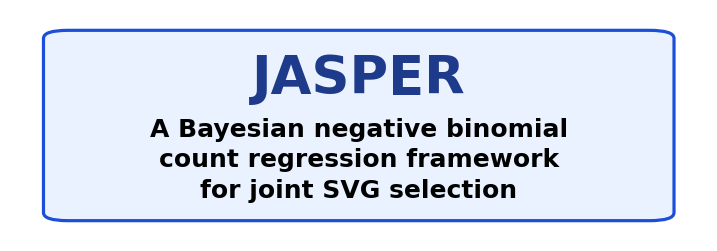

In [37]:
# ============================================================
# CARD 2: JASPER
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

JASPER_BG   = "#eaf2ff"
JASPER_EDGE = "#1d4ed8"
JASPER_TEXT = "#1e3a8a"

fig, ax = plt.subplots(figsize=(9, 3))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

card = FancyBboxPatch(
    (0.06, 0.10), 0.88, 0.80,
    boxstyle="round,pad=0.012,rounding_size=0.035",
    facecolor=JASPER_BG, edgecolor=JASPER_EDGE, linewidth=2.3
)
ax.add_patch(card)

ax.text(0.5, 0.70, "JASPER",
        ha="center", va="center", fontsize=38,
        color=JASPER_TEXT, fontweight="bold")

ax.text(
    0.5, 0.35,
    "A Bayesian negative binomial\ncount regression framework\nfor joint SVG selection",
    ha="center", va="center", fontsize=18,
    fontweight="bold", linespacing=1.35
)

plt.savefig("card_jasper.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

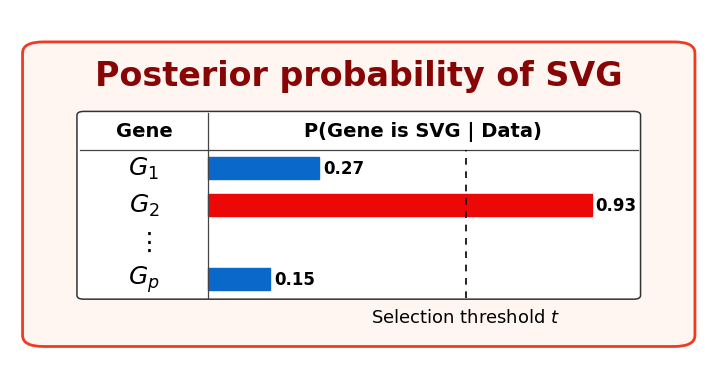

In [24]:
# ============================================================
# CARD 3: Output: Posterior probability of SVG
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

card = FancyBboxPatch(
    (0.03, 0.10), 0.94, 0.80,
    boxstyle="round,pad=0.012,rounding_size=0.03",
    facecolor="#fff5f1", edgecolor="#f13b20", linewidth=2
)
ax.add_patch(card)

ax.text(0.5, 0.82, "Posterior probability of SVG",
        ha="center", va="center", fontsize=24,
        color="#870505", fontweight="bold")

tx, ty, tw, th = 0.10, 0.22, 0.80, 0.50
table = FancyBboxPatch(
    (tx, ty), tw, th,
    boxstyle="round,pad=0.004,rounding_size=0.01",
    facecolor="white", edgecolor="#333333", linewidth=1.1
)
ax.add_patch(table)

label_w = 0.23 * tw
header_h = 0.20 * th
row_h = (th - header_h) / 4

ax.plot([tx + label_w, tx + label_w], [ty, ty + th], color="#444444", lw=0.9)
ax.plot([tx, tx + tw], [ty + th - header_h, ty + th - header_h], color="#444444", lw=0.9)

ax.text(tx + label_w/2, ty + th - header_h/2, "Gene",
        ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(tx + label_w + 0.5*(tw-label_w), ty + th - header_h/2,
        "P(Gene is SVG | Data)",
        ha="center", va="center", fontsize=14, fontweight="bold")

threshold = 0.60
xthr = tx + label_w + threshold*(tw-label_w)
ax.plot([xthr, xthr], [ty, ty + th - header_h],
        color="black", lw=1.2, linestyle=(0, (4, 4)))

labels = [r"$G_1$", r"$G_2$", r"$\vdots$", r"$G_p$"]
vals = [0.27, 0.93, None, 0.15]
cols = ["#0968c9", "#ed0808", None, "#0968c9"]

for i, lab in enumerate(labels):
    cy = ty + th - header_h - (i + 0.5) * row_h
    ax.text(tx + label_w/2, cy, lab,
            ha="center", va="center", fontsize=18, fontweight="bold")
    if vals[i] is None:
        #ax.text(tx + label_w + 0.50*(tw-label_w), cy, r"$\vdots$",
        #        ha="center", va="center", fontsize=20)
        pass
    else:
        bw = vals[i] * (tw - label_w) * 0.96
        bh = 0.60 * row_h
        bx = tx + label_w
        ax.add_patch(Rectangle((bx, cy - bh/2), bw, bh,
                               facecolor=cols[i], edgecolor=cols[i]))
        ax.text(bx + bw + 0.035, cy, f"{vals[i]:.2f}",
                ha="center", va="center", fontsize=12,
                color="black", fontweight="bold")

ax.text(xthr, ty - 0.03, r"Selection threshold $t$",
        ha="center", va="top", fontsize=13)

plt.savefig("card_output.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

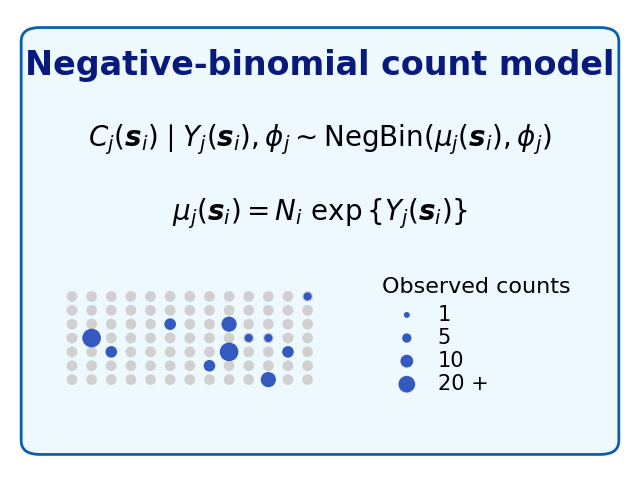

In [22]:
# ============================================================
# CARD 4: Negative-binomial counts model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

np.random.seed(3)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

card = FancyBboxPatch(
    (0.03, 0.05), 0.94, 0.90,
    boxstyle="round,pad=0.012,rounding_size=0.03",
    facecolor="#eef8ff", edgecolor="#0b5fb3", linewidth=2
)
ax.add_patch(card)

ax.text(0.5, 0.88, "Negative-binomial count model",
        ha="center", va="center", fontsize=24,
        color="#081a7c", fontweight="bold")

ax.text(0.5, 0.72,
        r"$C_j(\boldsymbol{s}_i)\mid Y_j(\boldsymbol{s}_i),\phi_j \sim \mathrm{NegBin}(\mu_j(\boldsymbol{s}_i),\phi_j)$",
        ha="center", va="center", fontsize=20)

ax.text(0.5, 0.56,
        r"$\mu_j(\boldsymbol{s}_i)=N_i\ \exp\{Y_j(\boldsymbol{s}_i)\}$",
        ha="center", va="center", fontsize=20)

# observed counts dot panel
px, py, pw, ph = 0.10, 0.20, 0.38, 0.18
xs = np.linspace(px, px + pw, 13)
ys = np.linspace(py, py + ph, 7)
xx, yy = np.meshgrid(xs, ys)
ax.scatter(xx.ravel(), yy.ravel(), s=60, color="#d0d0d0", edgecolors="none")

rng = np.random.RandomState(5)
idx = rng.choice(len(xx.ravel()), 11, replace=False)
sizes = rng.choice([35, 70, 120, 180], size=11)
ax.scatter(xx.ravel()[idx], yy.ravel()[idx], s=sizes,
           color="#3459c0", edgecolors="none")

ax.text(0.60, 0.40, "Observed counts",
        ha="left", va="center", fontsize=16)

legend_y = [0.34, 0.29, 0.24, 0.19]
legend_sizes = [18, 45, 85, 145]
legend_labels = ["1", "5", "10", "20 +"]

for yy, ss, lab in zip(legend_y, legend_sizes, legend_labels):
    ax.scatter([0.64], [yy], s=ss, color="#3459c0", edgecolors="none")
    ax.text(0.69, yy, lab, ha="left", va="center", fontsize=15)

plt.savefig("card_NB.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

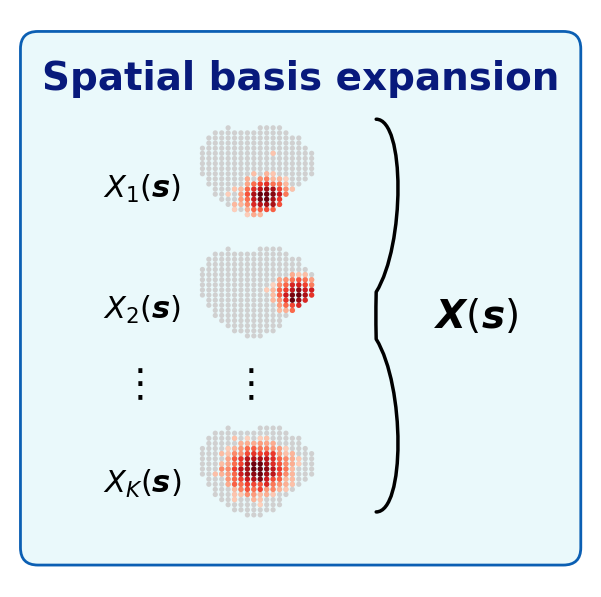

In [20]:
# ============================================================
# CARD 5: Spatial basis expansion
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, PathPatch
from matplotlib.path import Path

def draw_thin_right_brace(ax, x, y0, y1, width=0.045, lw=1.4, color="black"):
    ym = 0.5 * (y0 + y1)
    dy = y1 - y0

    verts = [
        (x, y1),
        (x + width, y1),          (x + width, ym + 0.18 * dy), (x, ym + 0.06 * dy),
        (x - 0.015 * width, ym),  (x - 0.015 * width, ym),     (x, ym - 0.06 * dy),
        (x + width, ym - 0.18 * dy), (x + width, y0),          (x, y0),
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
    ]

    patch = PathPatch(
        Path(verts, codes),
        facecolor="none",
        edgecolor=color,
        lw=lw,
        capstyle="round",
        joinstyle="round",
        zorder=10
    )
    ax.add_patch(patch)
    return patch

np.random.seed(2)

def tissue_points(n_side=20):
    xs = np.linspace(0.08, 0.92, n_side)
    ys = np.linspace(0.08, 0.92, n_side)
    xx, yy = np.meshgrid(xs, ys)
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    poly = np.array([
        [0.08, 0.64], [0.14, 0.78], [0.28, 0.88], [0.49, 0.86],
        [0.61, 0.92], [0.78, 0.80], [0.92, 0.62], [0.86, 0.42],
        [0.72, 0.30], [0.65, 0.16], [0.48, 0.10], [0.32, 0.18],
        [0.20, 0.31], [0.11, 0.46]
    ])
    return pts[Path(poly).contains_points(pts)]

def signal(pts, mode):
    x, y = pts[:, 0], pts[:, 1]
    if mode == "bottom":
        z = np.exp(-((x-0.56)**2+(y-0.28)**2)/0.025)
    elif mode == "right":
        z = np.exp(-((x-0.78)**2+(y-0.48)**2)/0.022)
    else:
        z = np.exp(-((x-0.50)**2+(y-0.52)**2)/0.045)
    z = z + 0.05*np.random.randn(len(z))
    z = np.clip(z, 0, None)
    return z / (z.max() + 1e-12)

def draw_map(ax, x, y, w, h, mode):
    pts = tissue_points()
    z = signal(pts, mode)
    xs = x + w*pts[:,0]
    ys = y + h*pts[:,1]
    ax.scatter(xs, ys, s=14, color="#d0d0d0", edgecolors="none")
    m = z > 0.18
    ax.scatter(xs[m], ys[m], s=15, c=z[m], cmap="Reds", vmin=0, vmax=1,
               edgecolors="none")

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

card = FancyBboxPatch(
    (0.03, 0.05), 0.94, 0.90,
    boxstyle="round,pad=0.012,rounding_size=0.03",
    facecolor="#eaf9fb", edgecolor="#0b5fb3", linewidth=2
)
ax.add_patch(card)

ax.text(0.5, 0.88, "Spatial basis expansion",
        ha="center", va="center", fontsize=28,
        color="#081a7c", fontweight="bold")

draw_map(ax, 0.30, 0.62, 0.25, 0.20, "bottom")
draw_map(ax, 0.30, 0.41, 0.25, 0.20, "right")
draw_map(ax, 0.30, 0.10, 0.25, 0.20, "center")

ax.text(0.16, 0.69, r"$X_1(\boldsymbol{s})$", fontsize=22, ha="left", va="center")
ax.text(0.16, 0.48, r"$X_2(\boldsymbol{s})$", fontsize=22, ha="left", va="center")
ax.text(0.16, 0.18, r"$X_K(\boldsymbol{s})$", fontsize=22, ha="left", va="center")
ax.text(0.21, 0.35, r"$\vdots$", fontsize=28, ha="center", va="center")
ax.text(0.40, 0.35, r"$\vdots$", fontsize=28, ha="center", va="center")

draw_thin_right_brace(ax, x=0.63, y0=0.13, y1=0.81, width=0.05, lw=2.5)
ax.text(0.73, 0.47, r"$\boldsymbol{X}(\boldsymbol{s})$",
        fontsize=28, ha="left", va="center", fontweight="bold")

plt.savefig("card_basis.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

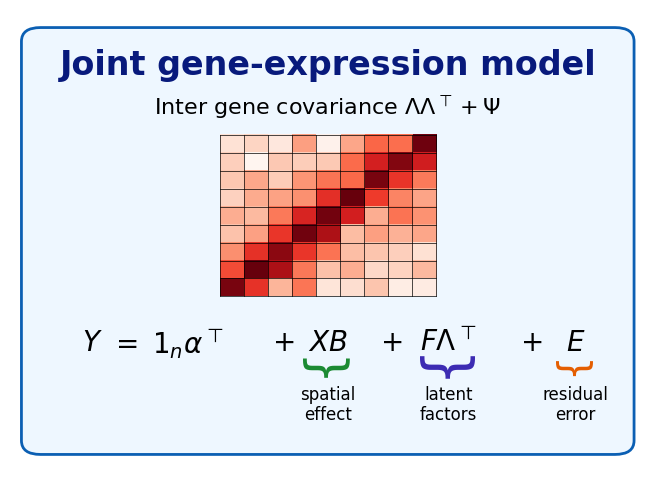

In [16]:
# ============================================================
# CARD 6: Joint gene-expression model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

np.random.seed(2)

fig, ax = plt.subplots(figsize=(8.2, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

card = FancyBboxPatch(
    (0.03, 0.05), 0.94, 0.90,
    boxstyle="round,pad=0.012,rounding_size=0.03",
    facecolor="#eef7ff", edgecolor="#0b5fb3", linewidth=2
)
ax.add_patch(card)

ax.text(0.5, 0.88, "Joint gene-expression model",
        ha="center", va="center", fontsize=24,
        color="#081a7c", fontweight="bold")

ax.text(0.5, 0.79, r"Inter gene covariance $\Lambda\Lambda^{\top}+\Psi$",
        ha="center", va="center", fontsize=16)

# heatmap
m = 9
A = np.zeros((m, m))
for i in range(m):
    for j in range(m):
        A[i, j] = 0.28 + 0.72 * np.exp(-abs(i - j) / 2.0)
A += 0.07 * np.random.randn(m, m)
A = np.clip(A, 0, 1)

hx, hy, hw, hh = 0.33, 0.38, 0.34, 0.35
ax.imshow(A, extent=(hx, hx + hw, hy, hy + hh),
          cmap="Reds", origin="lower", aspect="auto", zorder=2)

for k in range(m + 1):
    ax.plot([hx + k * hw / m, hx + k * hw / m], [hy, hy + hh],
            color="#000000", lw=0.5)
    ax.plot([hx, hx + hw], [hy + k * hh / m, hy + k * hh / m],
            color="#000000", lw=0.5)

# colorbar
# cbx, cby, cbw, cbh = 0.64, 0.45, 0.03, 0.22
# grad = np.linspace(0, 1, 200).reshape(-1, 1)
# ax.imshow(grad, extent=(cbx, cbx + cbw, cby, cby + cbh),
#           cmap="Reds", origin="lower", aspect="auto")
# ax.add_patch(Rectangle((cbx, cby), cbw, cbh, fill=False,
#                        edgecolor="#333333", linewidth=0.8))
# ax.text(cbx + 0.05, cby + cbh, "High", ha="left", va="center", fontsize=13)
# ax.text(cbx + 0.05, cby, "Low", ha="left", va="center", fontsize=13)

# equation pieces
eq_y = 0.28
pieces = [
    (0.13, r"$Y$", 20),
    (0.18, r"$=$", 20),
    (0.28, r"$1_n\alpha^{\top}$", 20),
    (0.43, r"$+$", 20),
    (0.50, r"$XB$", 20),
    (0.60, r"$+$", 20),
    (0.69, r"$F\Lambda^{\top}$", 20),
    (0.82, r"$+$", 20),
    (0.89, r"$E$", 20),
]
for xx, txt, fs in pieces:
    ax.text(xx, eq_y, txt, ha="center", va="center",
            fontsize=fs, fontweight="bold")

# manual underbraces
brace_y = 0.22
label_y = 0.145

ax.text(0.50, brace_y, r"$\{$", fontsize=36, rotation=90,
        ha="center", va="center", color="#1a8a32")
ax.text(0.50, label_y, "spatial\neffect",
        ha="center", va="center", fontsize=12)

ax.text(0.69, brace_y, r"$\{$", fontsize=42, rotation=90,
        ha="center", va="center", color="#3b2ab3")
ax.text(0.69, label_y, "latent\nfactors",
        ha="center", va="center", fontsize=12)

ax.text(0.89, brace_y, r"$\{$", fontsize=28, rotation=90,
        ha="center", va="center", color="#e45d00")
ax.text(0.89, label_y, "residual\nerror",
        ha="center", va="center", fontsize=12)

plt.savefig("card_joint.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

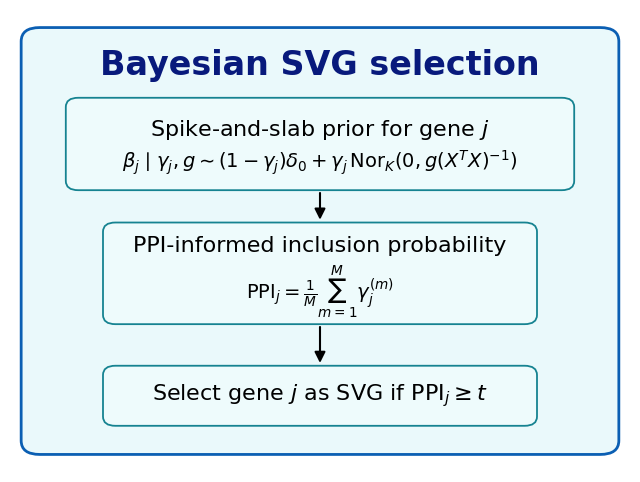

In [17]:
# ============================================================
# CARD 7: Bayesian SVG selection
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

card = FancyBboxPatch(
    (0.03, 0.05), 0.94, 0.90,
    boxstyle="round,pad=0.012,rounding_size=0.03",
    facecolor="#eaf9fb", edgecolor="#0b5fb3", linewidth=2
)
ax.add_patch(card)

ax.text(0.5, 0.88, "Bayesian SVG selection",
        ha="center", va="center", fontsize=24,
        color="#081a7c", fontweight="bold")

# top box
b1 = FancyBboxPatch(
    (0.10, 0.62), 0.80, 0.18,
    boxstyle="round,pad=0.01,rounding_size=0.02",
    facecolor="#eefbfc", edgecolor="#168391", linewidth=1.3
)
ax.add_patch(b1)

ax.text(0.5, 0.74, r"Spike-and-slab prior for gene $j$",
        ha="center", va="center", fontsize=16)
ax.text(0.5, 0.67,
        r"$\beta_j\mid\gamma_j,g\sim(1-\gamma_j)\delta_0+\gamma_j\,\mathrm{Nor}_K(0,g(X^{T}X)^{-1})$",
        ha="center", va="center", fontsize=14)

# arrow
ax.add_patch(FancyArrowPatch((0.5, 0.61), (0.5, 0.54),
                             arrowstyle="-|>", mutation_scale=16,
                             linewidth=1.5, color="black"))

# middle box
b2 = FancyBboxPatch(
    (0.16, 0.33), 0.68, 0.2,
    boxstyle="round,pad=0.01,rounding_size=0.02",
    facecolor="#eefbfc", edgecolor="#168391", linewidth=1.3
)
ax.add_patch(b2)

ax.text(0.5, 0.49, "PPI-informed inclusion probability",
        ha="center", va="center", fontsize=16)
ax.text(0.5, 0.39,
        r"$\mathrm{PPI}_j=\frac{1}{M}\sum_{m=1}^{M}\gamma_j^{(m)}$",
        ha="center", va="center", fontsize=14)

# arrow
ax.add_patch(FancyArrowPatch((0.5, 0.32), (0.5, 0.23),
                             arrowstyle="-|>", mutation_scale=16,
                             linewidth=1.5, color="black"))

# bottom box
b3 = FancyBboxPatch(
    (0.16, 0.11), 0.68, 0.11,
    boxstyle="round,pad=0.01,rounding_size=0.02",
    facecolor="#eefbfc", edgecolor="#168391", linewidth=1.3
)
ax.add_patch(b3)

ax.text(0.5, 0.165,
        r"Select gene $j$ as SVG if $\mathrm{PPI}_j\geq t$",
        ha="center", va="center", fontsize=16)

plt.savefig("card_select.png", dpi=400, bbox_inches="tight", pad_inches=0.03)

plt.show()

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrowPatch, PathPatch
from matplotlib.path import Path


# ============================================================
# Input card image files
# Replace these filenames by your saved card files
# ============================================================

CARD_INPUT  = "card_input.png"
CARD_JASPER = "card_jasper.png"
CARD_OUTPUT = "card_output.png"
CARD_NB     = "card_NB.png"
CARD_BASIS  = "card_basis.png"
CARD_JOINT  = "card_joint.png"
CARD_SVG    = "card_select.png"


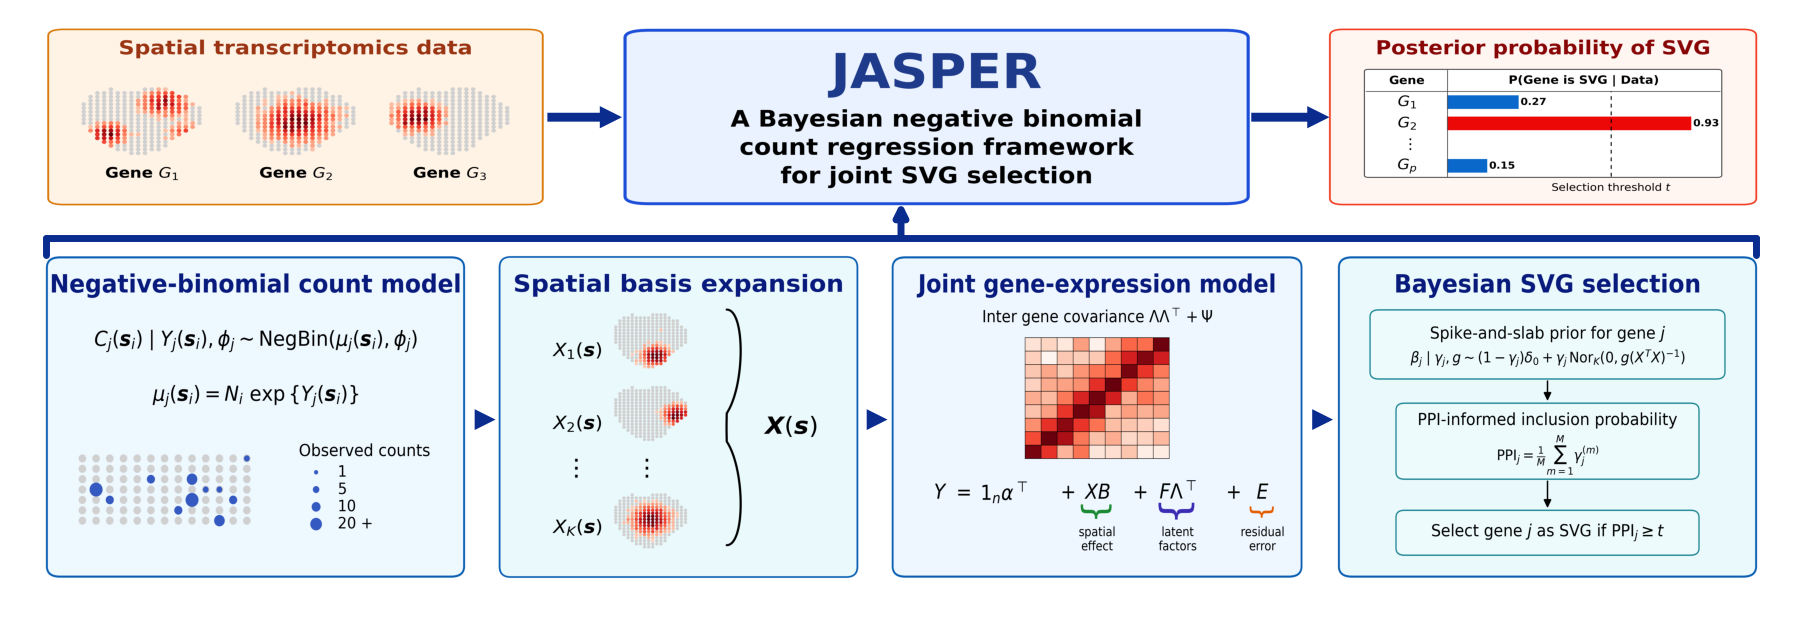

In [38]:

# ============================================================
# Helpers
# ============================================================

def add_card_image(ax, filename, x, y, w, h):
    """
    Add a saved card image inside the rectangle [x,x+w] x [y,y+h].
    """
    img = mpimg.imread(filename)
    ax.imshow(
        img,
        extent=(x, x + w, y, y + h),
        aspect="auto",
        zorder=2
    )


def add_arrow(ax, start, end, color="#0a2c8f", scale=38):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="simple",
        mutation_scale=scale,
        fc=color,
        ec=color,
        lw=0,
        zorder=10
    )
    ax.add_patch(arrow)


def draw_rectangular_brace(ax, x0, x1, y, height=0.045, lw=2.0, color="black"):
    """
    Draw a rectangular brace spanning [x0, x1], with a small arrow pointing up.
    """
    xm = 0.5 * (x0 + x1)

    # horizontal bar
    ax.plot(
        [x0, x1],
        [y, y],
        color=color,
        lw=lw,
        solid_capstyle="round",
        zorder=8
    )

    # vertical end ticks
    ax.plot(
        [x0, x0],
        [y, y - height],
        color=color,
        lw=lw,
        solid_capstyle="round",
        zorder=8
    )
    ax.plot(
        [x1, x1],
        [y, y - height],
        color=color,
        lw=lw,
        solid_capstyle="round",
        zorder=8
    )

    # upward arrow from midpoint to JASPER
    ax.add_patch(
        FancyArrowPatch(
            (xm, y),
            (xm, y + 0.045),
            arrowstyle="-|>",
            mutation_scale=18,
            lw=lw,
            color=color,
            zorder=9
        )
    )


# ============================================================
# Assemble final figure
# ============================================================

fig, ax = plt.subplots(figsize=(18, 6.3))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.7)
ax.axis("off")


# ------------------------------------------------------------
# Top row cards
# ------------------------------------------------------------

add_card_image(ax, CARD_INPUT,  0.015, 0.450, 0.290, 0.250)
add_card_image(ax, CARD_JASPER, 0.325, 0.450, 0.390, 0.250)
add_card_image(ax, CARD_OUTPUT, 0.735, 0.450, 0.250, 0.250)

# Top arrows
add_arrow(ax, (0.300, 0.575), (0.345, 0.575), scale=32)
add_arrow(ax, (0.695, 0.575), (0.742, 0.575), scale=32)

# ------------------------------------------------------------
# Bottom row cards
# ------------------------------------------------------------

add_card_image(ax, CARD_NB,     0.015, 0.025, 0.245, 0.405) #0.115
add_card_image(ax, CARD_BASIS,  0.270, 0.025, 0.210, 0.405)
add_card_image(ax, CARD_JOINT,  0.490, 0.025, 0.240, 0.405)
add_card_image(ax, CARD_SVG,    0.740, 0.025, 0.245, 0.405)

add_arrow(ax, (0.262, 0.225), (0.274, 0.225), scale=30)
add_arrow(ax, (0.482, 0.225), (0.494, 0.225), scale=30)
add_arrow(ax, (0.732, 0.225), (0.744, 0.225), scale=30)


# ------------------------------------------------------------
# Curly brace from bottom components to JASPER
# ------------------------------------------------------------


draw_rectangular_brace(ax, x0=0.020, x1=0.980, y=0.435, height=0.020, lw=5.0, color = "#0a2c8f")


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.subplots_adjust(left=0.005, right=0.995, bottom=0.02, top=0.98)

plt.savefig("JASPER_combined_schematic.png", dpi=400, bbox_inches="tight", pad_inches=0.05)

plt.show()